In [1]:
# =========================
# 1. 설치
# =========================
!pip install -q roboflow pycocotools torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 55.2 MB/s eta 0:00:00


In [2]:
# ============================================================
# Faster R-CNN + Roboflow COCO JSON 전체 코드
# Roboflow project: elecourse-atjrg / merge_0626_3 / version 13
# ============================================================

# 1. 설치


# 2. Roboflow COCO JSON 데이터셋 다운로드
from roboflow import Roboflow

rf = Roboflow(api_key="byjMEhXUKbKas3eLE2V9")
project = rf.workspace("elecourse-atjrg").project("merge_0626_3")
version = project.version(13)

# Faster R-CNN용: COCO JSON
dataset = version.download("coco")

DATASET_ROOT = dataset.location
print("DATASET_ROOT:", DATASET_ROOT)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to merge_0626_3-13 in coco:: 100%|██████████| 3222/3222 [00:01<00:00, 2935.03it/s]

DATASET_ROOT: /content/merge_0626_3-13


In [3]:
# ============================================================
# 3. 라이브러리 import
# ============================================================

import os
import json
import time
import random
from pathlib import Path
from PIL import Image

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from pycocotools.coco import COCO
from torchmetrics.detection.mean_ap import MeanAveragePrecision

import matplotlib.pyplot as plt
import matplotlib.patches as patches

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 device:", device)

# 재현성 조금 고정
torch.manual_seed(42)
random.seed(42)

사용 device: cuda


In [4]:
# ============================================================
# 4. Roboflow COCO Dataset 클래스
# ============================================================

class RoboflowCocoDataset(Dataset):
    def __init__(self, root, split="train", cat_id_to_label=None):
        self.root = Path(root)
        self.split = split
        self.split_dir = self.root / split
        self.ann_file = self.split_dir / "_annotations.coco.json"

        if not self.ann_file.exists():
            raise FileNotFoundError(f"annotation 파일 없음: {self.ann_file}")

        self.coco = COCO(str(self.ann_file))
        self.img_ids = sorted(list(self.coco.imgs.keys()))

        # category 정보 읽기
        cats = self.coco.loadCats(self.coco.getCatIds())
        cats = sorted(cats, key=lambda x: x["id"])

        # Faster R-CNN에서 label 0은 background라서 실제 클래스는 1부터 시작
        if cat_id_to_label is None:
            self.cat_id_to_label = {cat["id"]: i + 1 for i, cat in enumerate(cats)}
        else:
            self.cat_id_to_label = cat_id_to_label

        self.label_to_name = {}
        for cat in cats:
            if cat["id"] in self.cat_id_to_label:
                new_label = self.cat_id_to_label[cat["id"]]
                self.label_to_name[new_label] = cat["name"]

        self.num_classes = len(self.label_to_name) + 1  # background 포함

        print(f"\n[{split}]")
        print("이미지 수:", len(self.img_ids))
        print("클래스 매핑:", self.label_to_name)
        print("num_classes(background 포함):", self.num_classes)

    def __len__(self):
        return len(self.img_ids)

    def _find_image_path(self, file_name):
        candidates = [
            self.split_dir / file_name,
            self.split_dir / "images" / file_name,
            self.root / self.split / file_name,
            self.root / self.split / "images" / file_name,
        ]

        for p in candidates:
            if p.exists():
                return p

        raise FileNotFoundError(f"이미지 파일을 찾을 수 없음: {file_name}")

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        file_name = img_info["file_name"]

        img_path = self._find_image_path(file_name)
        image = Image.open(img_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=[img_id])
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        width = img_info.get("width", image.width)
        height = img_info.get("height", image.height)

        for ann in anns:
            x, y, w, h = ann["bbox"]

            # 잘못된 박스 제거
            if w <= 1 or h <= 1:
                continue

            x1 = max(0, x)
            y1 = max(0, y)
            x2 = min(width, x + w)
            y2 = min(height, y + h)

            if x2 <= x1 or y2 <= y1:
                continue

            cat_id = ann["category_id"]

            if cat_id not in self.cat_id_to_label:
                continue

            boxes.append([x1, y1, x2, y2])
            labels.append(self.cat_id_to_label[cat_id])
            areas.append(ann.get("area", w * h))
            iscrowd.append(ann.get("iscrowd", 0))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        if boxes.numel() == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor(img_id),
            "area": areas,
            "iscrowd": iscrowd,
        }

        image = F.to_tensor(image)

        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))

In [5]:
# ============================================================
# 5. Dataset / DataLoader 생성
# ============================================================

train_dataset = RoboflowCocoDataset(DATASET_ROOT, split="train")

# valid 폴더가 있으면 valid 사용, 없으면 test 사용
if (Path(DATASET_ROOT) / "valid").exists():
    valid_split = "valid"
elif (Path(DATASET_ROOT) / "test").exists():
    valid_split = "test"
else:
    raise FileNotFoundError("valid 또는 test 폴더가 없습니다.")

valid_dataset = RoboflowCocoDataset(
    DATASET_ROOT,
    split=valid_split,
    cat_id_to_label=train_dataset.cat_id_to_label
)

NUM_CLASSES = train_dataset.num_classes

# T4 기준 Faster R-CNN은 batch_size 2도 버거울 수 있음.
# 메모리 터지면 batch_size=1로 바꾸면 됨.
BATCH_SIZE = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print("NUM_CLASSES:", NUM_CLASSES)
print("train batch 수:", len(train_loader))
print("valid batch 수:", len(valid_loader))

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!

[train]
이미지 수: 2955
클래스 매핑: {1: 'computer-elements-062621', 2: 'GPU', 3: 'RAM', 4: 'RAM_slot', 5: 'eraser', 6: 'hand', 7: 'monitor', 8: 'power_button_LED'}
num_classes(background 포함): 9
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!

[valid]
이미지 수: 137
클래스 매핑: {1: 'computer-elements-062621', 2: 'GPU', 3: 'RAM', 4: 'RAM_slot', 5: 'eraser', 6: 'hand', 7: 'monitor', 8: 'power_button_LED'}
num_classes(background 포함): 9
NUM_CLASSES: 9
train batch 수: 1478
valid batch 수: 137


In [6]:
# ============================================================
# 6. Faster R-CNN 모델 생성
# ============================================================

def get_faster_rcnn_model(num_classes):
    # COCO pretrained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # 기존 COCO head를 우리 클래스 수에 맞게 교체
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


model = get_faster_rcnn_model(NUM_CLASSES)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Faster R-CNN 준비 완료")
print(f"전체 파라미터 수: {total_params:,}")
print(f"학습 파라미터 수: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 190MB/s]


Faster R-CNN 준비 완료
전체 파라미터 수: 41,335,036
학습 파라미터 수: 41,112,636


In [7]:
# ============================================================
# 7. 학습 설정
# ============================================================

EPOCHS = 20
LR = 0.005

params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=LR,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

print("EPOCHS:", EPOCHS)
print("LR:", LR)

EPOCHS: 20
LR: 0.005


In [8]:
# ============================================================
# 8. 학습 함수
# ============================================================

def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()

    total_loss = 0.0
    start_time = time.time()

    for step, (images, targets) in enumerate(data_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        if step % 20 == 0:
            loss_items = {k: round(v.item(), 4) for k, v in loss_dict.items()}
            print(
                f"Epoch [{epoch+1}/{EPOCHS}] "
                f"Step [{step}/{len(data_loader)}] "
                f"Loss: {losses.item():.4f} | {loss_items}"
            )

    avg_loss = total_loss / len(data_loader)
    elapsed = time.time() - start_time

    print(f"Epoch [{epoch+1}] 평균 Loss: {avg_loss:.4f} | 시간: {elapsed:.1f}s")
    return avg_loss

In [9]:
# ============================================================
# 9. 검증 함수: mAP 계산
# ============================================================

@torch.no_grad()
def evaluate_map(model, data_loader, device):
    model.eval()

    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        preds = []
        gts = []

        for output, target in zip(outputs, targets):
            preds.append({
                "boxes": output["boxes"].detach().cpu(),
                "scores": output["scores"].detach().cpu(),
                "labels": output["labels"].detach().cpu(),
            })

            gts.append({
                "boxes": target["boxes"].detach().cpu(),
                "labels": target["labels"].detach().cpu(),
            })

        metric.update(preds, gts)

    result = metric.compute()

    map_5095 = float(result["map"])
    map_50 = float(result["map_50"])
    map_75 = float(result["map_75"])

    print("검증 결과")
    print(f"mAP 50-95: {map_5095:.4f}")
    print(f"mAP 50:    {map_50:.4f}")
    print(f"mAP 75:    {map_75:.4f}")

    return result

In [10]:
# ============================================================
# 10. 추론 속도 측정 함수
# ============================================================

@torch.no_grad()
def benchmark_fps(model, dataset, device, num_images=50):
    model.eval()

    n = min(num_images, len(dataset))
    indices = list(range(n))

    # GPU warm-up
    for i in indices[:5]:
        image, _ = dataset[i]
        _ = model([image.to(device)])

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    for i in indices:
        image, _ = dataset[i]
        _ = model([image.to(device)])

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start
    fps = n / elapsed
    ms_per_image = (elapsed / n) * 1000

    print(f"측정 이미지 수: {n}")
    print(f"총 시간: {elapsed:.3f}s")
    print(f"평균 ms/image: {ms_per_image:.2f} ms")
    print(f"FPS: {fps:.2f}")

    return fps, ms_per_image

In [11]:
# ============================================================
# 11. 학습 실행
# ============================================================

best_map = 0.0
save_path = "/content/fasterrcnn_roboflow_v13_best.pth"

history = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch)
    lr_scheduler.step()

    result = evaluate_map(model, valid_loader, device)
    current_map = float(result["map"])
    current_map50 = float(result["map_50"])

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "map_50_95": current_map,
        "map_50": current_map50,
    })

    if current_map > best_map:
        best_map = current_map
        torch.save({
            "model_state_dict": model.state_dict(),
            "num_classes": NUM_CLASSES,
            "label_to_name": train_dataset.label_to_name,
            "cat_id_to_label": train_dataset.cat_id_to_label,
            "best_map": best_map,
            "epoch": epoch + 1,
        }, save_path)

        print(f"Best model 저장됨: {save_path} | best mAP: {best_map:.4f}")

print("Faster R-CNN 학습 완료")
print("최고 mAP 50-95:", best_map)

Epoch [1/20] Step [0/1478] Loss: 2.6782 | {'loss_classifier': 2.4199, 'loss_box_reg': 0.1426, 'loss_objectness': 0.0238, 'loss_rpn_box_reg': 0.0919}
Epoch [1/20] Step [20/1478] Loss: 0.4336 | {'loss_classifier': 0.1623, 'loss_box_reg': 0.1095, 'loss_objectness': 0.144, 'loss_rpn_box_reg': 0.0178}
Epoch [1/20] Step [40/1478] Loss: 0.2561 | {'loss_classifier': 0.126, 'loss_box_reg': 0.0819, 'loss_objectness': 0.04, 'loss_rpn_box_reg': 0.0083}
Epoch [1/20] Step [60/1478] Loss: 0.6154 | {'loss_classifier': 0.2835, 'loss_box_reg': 0.2413, 'loss_objectness': 0.0418, 'loss_rpn_box_reg': 0.0488}
Epoch [1/20] Step [80/1478] Loss: 0.2581 | {'loss_classifier': 0.1199, 'loss_box_reg': 0.1115, 'loss_objectness': 0.0235, 'loss_rpn_box_reg': 0.0032}
Epoch [1/20] Step [100/1478] Loss: 0.2446 | {'loss_classifier': 0.1114, 'loss_box_reg': 0.0555, 'loss_objectness': 0.0631, 'loss_rpn_box_reg': 0.0146}
Epoch [1/20] Step [120/1478] Loss: 0.2973 | {'loss_classifier': 0.1078, 'loss_box_reg': 0.0688, 'loss_ob

In [12]:
# ============================================================
# 12. 최종 best 모델 로드 후 평가 + 속도 측정
# ============================================================

checkpoint = torch.load(save_path, map_location=device)

model = get_faster_rcnn_model(checkpoint["num_classes"])
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

label_to_name = checkpoint["label_to_name"]

print("Best epoch:", checkpoint["epoch"])
print("Best mAP:", checkpoint["best_map"])
print("label_to_name:", label_to_name)

final_metrics = evaluate_map(model, valid_loader, device)
fps, ms_per_image = benchmark_fps(model, valid_dataset, device, num_images=50)

Best epoch: 8
Best mAP: 0.5561229586601257
label_to_name: {1: 'computer-elements-062621', 2: 'GPU', 3: 'RAM', 4: 'RAM_slot', 5: 'eraser', 6: 'hand', 7: 'monitor', 8: 'power_button_LED'}
검증 결과
mAP 50-95: 0.5561
mAP 50:    0.8207
mAP 75:    0.5976
측정 이미지 수: 50
총 시간: 4.775s
평균 ms/image: 95.50 ms
FPS: 10.47


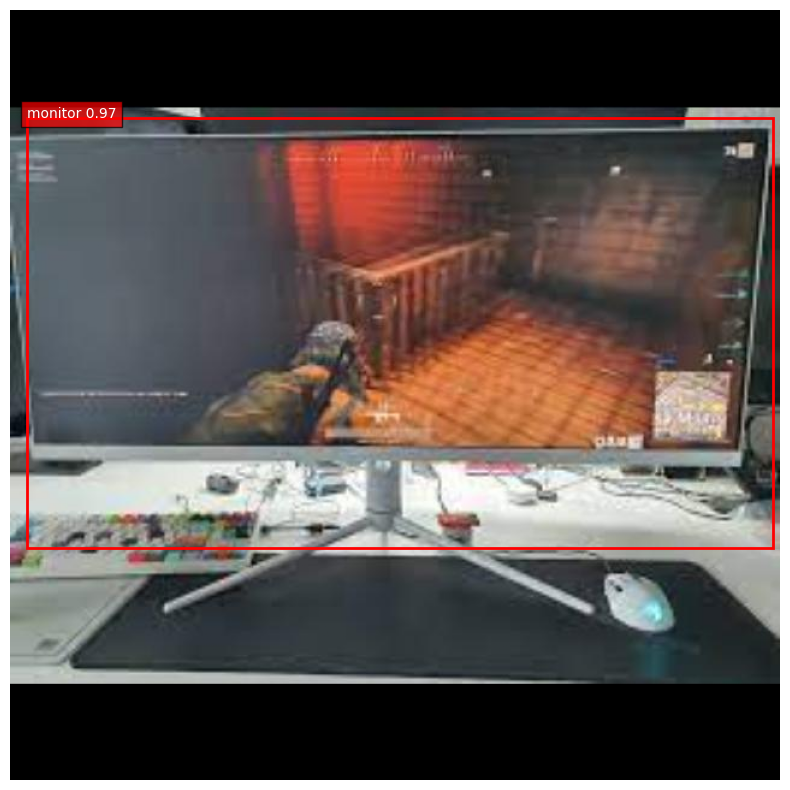

In [13]:
# ============================================================
# 13. 예측 결과 시각화
# ============================================================

idx = random.randint(0, len(valid_dataset) - 1)
image, target = valid_dataset[idx]

with torch.no_grad():
    output = model([image.to(device)])[0]

img_np = image.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(10, 10))
plt.imshow(img_np)

ax = plt.gca()
score_threshold = 0.3

for box, label, score in zip(output["boxes"], output["labels"], output["scores"]):
    score = float(score.detach().cpu())

    if score < score_threshold:
        continue

    x1, y1, x2, y2 = box.detach().cpu().numpy()
    cls_id = int(label.detach().cpu())
    cls_name = label_to_name.get(cls_id, str(cls_id))

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)
    ax.text(
        x1,
        y1,
        f"{cls_name} {score:.2f}",
        color="white",
        bbox=dict(facecolor="red", alpha=0.7)
    )

plt.axis("off")
plt.show()

In [14]:
# ============================================================
# 14. 발표용 결과 요약 출력
# ============================================================

final_map = float(final_metrics["map"])
final_map50 = float(final_metrics["map_50"])
final_map75 = float(final_metrics["map_75"])

print("========== Faster R-CNN 발표용 요약 ==========")
print("Model: Faster R-CNN ResNet50-FPN")
print(f"Dataset: Roboflow merge_0626_3 version 13 / COCO JSON")
print(f"mAP 50-95: {final_map:.4f}")
print(f"mAP 50:    {final_map50:.4f}")
print(f"mAP 75:    {final_map75:.4f}")
print(f"FPS:        {fps:.2f}")
print(f"ms/image:   {ms_per_image:.2f}")
print(f"Params:     {total_params:,}")
print("============================================")

========== Faster R-CNN 발표용 요약 ==========
Model: Faster R-CNN ResNet50-FPN
Dataset: Roboflow merge_0626_3 version 13 / COCO JSON
mAP 50-95: 0.5561
mAP 50:    0.8207
mAP 75:    0.5976
FPS:        10.47
ms/image:   95.50
Params:     41,335,036
